# BreastMNIST: LibAUC vs. a BCE baseline

## Overview

Binary classification of 28x28 grayscale breast ultrasound images. Label 0 is malignant (the minority), label 1 is normal/benign. Train / val / test = 546 / 78 / 156. Train has 147 malignant (27%), test has 42.

Arms:
- Baseline: ResNet-18 + `BCEWithLogitsLoss` + Adam, no augmentation, no balancing.
- Hand-picked, Models 1 to 4: ResNet-20 + LibAUC `AUCMLoss_V2` + `PESG`, `DualSampler`, fixed hyperparameters. The models differ in augmentation (flip, Gaussian noise, normalization).
- Optuna-tuned: the Model 4 recipe after a 30-trial search, retrained for up to 50 epochs.

All four hand-picked models beat the Baseline on test ROC-AUC, but only the Baseline and Optuna-tuned have every metric, and there Optuna-tuned is ahead on everything except malignant precision. Model 1 (flip + noise) has the highest ROC-AUC of any arm. Adding normalization to Model 1 (that is Model 4) did not help, and tuning closes only part of the gap to Model 1.

Notes:
- ResNet-18 starts with a 7x7 stride-2 conv and a max-pool, so a 28x28 input is 7x7 before the first stage and 1x1 at the last. ResNet-20 starts with a 3x3 stride-1 conv and no max-pool and ends at 7x7.
- `AUCMLoss_V2` needs both classes in every batch. `DualSampler(sampling_rate=r)` draws a fraction `r` of each batch from label 1 (the majority), so 0.7 gives about 30% malignant.
- Arms train for up to 50 epochs with patience 12. An epoch counts toward patience when its validation ROC-AUC is at most 0.005 above the previous epoch's. The best-validation checkpoint is restored.

## Setup

Installs `medmnist`, `libauc==1.2.0` (pinned) and `optuna`.

In [1]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 12.9 MB/s eta 0:00:00


In [2]:
!pip install libauc==1.2.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 7.7 MB/s eta 0:00:00


In [4]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 28.8 MB/s eta 0:00:00


### Imports

Training and evaluation helpers (`train`, `train_with_logits_loss`, `OnTheFlyAugment`, `AddGaussianNoise`) are in `dataCentric_functions.py`. The Optuna helpers are in `hyperparameter_tuning.py`.

In [6]:
from sklearn import metrics
import numpy as np
import torch
import torch.nn as nn
import torch.utils.data as data
import torchvision.transforms as transforms

import medmnist
from medmnist import INFO

In [7]:
from libauc.losses import AUCMLoss_V2  # libauc 1.2.0: AUCMLoss_V2 is a separate class (no version= kwarg)
from libauc.optimizers import PESG
from libauc.models import resnet20 as ResNet20
from libauc.sampler import DualSampler

import torch
import numpy as np
import torchvision.transforms as transforms
from dataCentric_functions import *


In [8]:
import matplotlib.pyplot as plt

## Data

BreastMNIST from `medmnist`: 28x28, 1 channel, converted with `ToTensor()` so pixel values are in [0,1].

In [9]:
data_flag = 'breastmnist'
download = True

BATCH_SIZE = 128

info = INFO[data_flag]
n_channels = info['n_channels']

DataClass = getattr(medmnist, info['python_class'])

In [10]:
data_transform1 = transforms.Compose([
    transforms.ToTensor()
])


In [11]:
train_dataset1 = DataClass(split='train', transform=data_transform1, download=download)
val_dataset1 = DataClass(split='val', transform=data_transform1, download=download)
test_dataset = DataClass(split='test', transform=data_transform1, download=download)

train_dataset1

100%|██████████| 560k/560k [00:01<00:00, 484kB/s]


Dataset BreastMNIST of size 28 (breastmnist)
    Number of datapoints: 546
    Root location: /root/.medmnist
    Split: train
    Task: binary-class
    Number of channels: 1
    Meaning of labels: {'0': 'malignant', '1': 'normal, benign'}
    Number of samples: {'train': 546, 'val': 78, 'test': 156}
    Description: The BreastMNIST is based on a dataset of 780 breast ultrasound images. It is categorized into 3 classes: normal, benign, and malignant. As we use low-resolution images, we simplify the task into binary classification by combining normal and benign as positive and classifying them against malignant as negative. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images of 1×500×500 are resized into 1×28×28.
    License: CC BY 4.0

## Baseline

ResNet-18 (ImageNet-style stem, see Overview) with `nn.BCEWithLogitsLoss()` and Adam (lr 1e-3), 1 channel in, 1 logit out. No augmentation, no balancing: a plain shuffled `DataLoader` at the natural class frequencies.

`train_with_logits_loss` validates after the first minibatch of each epoch, so the epoch in its restore message counts full epochs plus one step. The AUC-margin arms validate after each full epoch.

In [13]:
# plain shuffled loader, no augmentation
baseline_trainloader = data.DataLoader(dataset=train_dataset1, batch_size=BATCH_SIZE, shuffle=True)
baseline_valloader = data.DataLoader(dataset=val_dataset1, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
baseline_trainloader_eval = data.DataLoader(dataset=train_dataset1, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [14]:
# ResNet-18: ImageNet-style stem, see Overview
from libauc.models import resnet18 as ResNet18

baseline_model = ResNet18(pretrained=False, last_activation=None, num_classes=1)
baseline_model.conv1 = torch.nn.Conv2d(n_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)

# HyperParameters
baseline_epochs = 50
baseline_patience = 12
baseline_lr = 1e-3

# BCE on raw logits + Adam
baseline_loss_fn = nn.BCEWithLogitsLoss()
baseline_optimizer = torch.optim.Adam(baseline_model.parameters(), lr=baseline_lr)

In [15]:
# returns None, restores the best-val checkpoint into baseline_model in place
train_with_logits_loss(baseline_model, baseline_loss_fn, baseline_optimizer, baseline_epochs,
                       baseline_trainloader, baseline_trainloader_eval, baseline_valloader,
                       patience=baseline_patience)

Start Training
------------------------------
device: cuda
Epoch=0, BatchID=0, Val_AUC=0.7009
0
Epoch=1, BatchID=0, Val_AUC=0.7310
0
Epoch=2, BatchID=0, Val_AUC=0.7168
1
Epoch=3, BatchID=0, Val_AUC=0.6959
2
Epoch=4, BatchID=0, Val_AUC=0.8028
0
Epoch=5, BatchID=0, Val_AUC=0.7962
1
Epoch=6, BatchID=0, Val_AUC=0.7009
2
Epoch=7, BatchID=0, Val_AUC=0.8187
0
Epoch=8, BatchID=0, Val_AUC=0.8346
0
Epoch=9, BatchID=0, Val_AUC=0.8137
1
Epoch=10, BatchID=0, Val_AUC=0.8881
0
Epoch=11, BatchID=0, Val_AUC=0.8997
0
Epoch=12, BatchID=0, Val_AUC=0.9323
0
Epoch=13, BatchID=0, Val_AUC=0.8964
1
Epoch=14, BatchID=0, Val_AUC=0.9114
0
Epoch=15, BatchID=0, Val_AUC=0.8404
1
Epoch=16, BatchID=0, Val_AUC=0.8396
2
Epoch=17, BatchID=0, Val_AUC=0.8747
0
Epoch=18, BatchID=0, Val_AUC=0.9114
0
Epoch=19, BatchID=0, Val_AUC=0.9098
1
Epoch=20, BatchID=0, Val_AUC=0.8680
2
Epoch=21, BatchID=0, Val_AUC=0.8020
3
Epoch=22, BatchID=0, Val_AUC=0.8739
0
Epoch=23, BatchID=0, Val_AUC=0.8947
0
Epoch=24, BatchID=0, Val_AUC=0.8897
1
E

In [17]:
# test ROC-AUC (the trainer already moved the model to `device`)
baseline_test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# eval mode: BatchNorm uses running statistics. Training leaves the model in train mode,
# where predictions would depend on batch composition
baseline_model.eval()
score_list = list()
label_list = list()
with torch.no_grad():
    for _, d in enumerate(baseline_test_loader, 0):
        tmp_data, tmp_label = d
        tmp_data = tmp_data.to(device)
        tmp_score = torch.sigmoid(baseline_model(tmp_data)).detach().clone().cpu()
        score_list.append(tmp_score)
        label_list.append(tmp_label.cpu())

baseline_test_label = torch.cat(label_list)
baseline_test_score = torch.cat(score_list)

baseline_test_auc = metrics.roc_auc_score(baseline_test_label, baseline_test_score)
print("Test AUC (baseline): %.4f" % baseline_test_auc, flush=True)

Test AUC (baseline): 0.8127


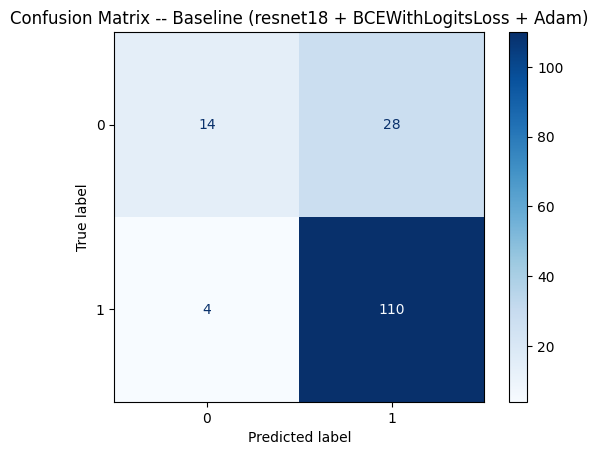

              precision    recall  f1-score   support

           0     0.7778    0.3333    0.4667        42
           1     0.7971    0.9649    0.8730       114

    accuracy                         0.7949       156
   macro avg     0.7874    0.6491    0.6698       156
weighted avg     0.7919    0.7949    0.7636       156

Balanced accuracy: 0.6491
PR-AUC (average precision): 0.8871
Matthews correlation coefficient: 0.4141


In [18]:
# confusion matrix and threshold metrics at 0.5 for the Baseline
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                              balanced_accuracy_score, average_precision_score, matthews_corrcoef)

prob = baseline_test_score.numpy().reshape(-1)  # already a sigmoid probability
y_true = baseline_test_label.numpy().astype(int).reshape(-1)
y_pred = (prob >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title('Confusion Matrix -- Baseline (resnet18 + BCEWithLogitsLoss + Adam)')
plt.show()

print(classification_report(y_true, y_pred, digits=4))
print('Balanced accuracy: %.4f' % balanced_accuracy_score(y_true, y_pred))
# PR-AUC is for label 1 (normal/benign, the majority class)
print('PR-AUC (average precision): %.4f' % average_precision_score(y_true, prob))
print('Matthews correlation coefficient: %.4f' % matthews_corrcoef(y_true, y_pred))

In [19]:
torch.save(baseline_model.state_dict(), "breast_baseline.pth")

## Class balance

Train has 147 malignant (label 0, 27%) and 399 normal/benign (label 1), printed below. The Baseline trains on this as is. Every other arm rebalances batches with a `DualSampler`.

In [20]:
# class ratio within train_dataset1 only
train_counts = np.unique(train_dataset1.labels, return_counts=True)
print(f"class ratio (train): {train_counts}")
neg_counts, pos_counts = train_counts[1][0], train_counts[1][1]
neg_counts

class ratio (train): (array([0, 1], dtype=uint8), array([147, 399]))


np.int64(147)

In [21]:
# augmentation helpers (OnTheFlyAugment and AddGaussianNoise come from dataCentric_functions.py)
import random

def flip_aug(img):
    return transforms.functional.hflip(img)

def noise_aug(img):
    # Gaussian noise, std 0.08 on the [0,1] pixel scale
    return AddGaussianNoise(0., 0.08)(img)

def normalize_aug(img):
    return transforms.functional.normalize(img, mean=[.5], std=[.5])

def make_augment(funcs, p=0.5):
    def augment(img):
        for f in funcs:
            if random.random() < p:
                img = f(img)
        return img
    return augment

def make_augment_with_normalize(funcs, p=0.5):
    # random flip/noise (each with probability p), then normalize to [-1,1] as the last step
    stochastic = make_augment(funcs, p=p)
    def augment(img):
        return normalize_aug(stochastic(img))
    return augment

val_d = val_dataset1  # raw [0,1] val set (Model 1 does not normalize)

## Augmentation ablation

Four ResNet-20 models (`resnet20`, 16 stem channels, 1 logit, stem as in Overview) with `AUCMLoss_V2` (margin 1.0), `PESG` (lr 0.05, momentum 0.9, epoch_decay 0.003, weight decay 5e-4) and `DualSampler(sampling_rate=0.7)`. They differ only in augmentation and the matching normalization.

| Model | Training augmentation | Val / test preprocessing |
|---|---|---|
| 1 | flip + Gaussian noise | raw [0,1] |
| 2 | flip + normalize | normalize |
| 3 | Gaussian noise + normalize | normalize |
| 4 | flip + noise + normalize | normalize |

Flip and noise are each applied with p = 0.5 (noise std 0.08). Normalize is (x - 0.5) / 0.5 and is always applied, so train and eval share one input scale. Up to 50 epochs, LR and regularizer decay by 10x at epochs 25 and 40, patience 12, batch size 128. The Optuna search is centered on these hand-picked values.

### Model 1: flip + noise

In [22]:
# Model 1: flip + noise, raw [0,1] inputs
train_d = OnTheFlyAugment(train_dataset1, make_augment([flip_aug, noise_aug]))
# DualSampler: sampling_rate 0.7 gives ~30% malignant per batch, see Overview
sampler_dual = DualSampler(train_d, batch_size=BATCH_SIZE, labels=train_dataset1.labels, sampling_rate=0.7)
trainloader = data.DataLoader(dataset=train_d, batch_size=BATCH_SIZE, sampler=sampler_dual)
valloader = data.DataLoader(dataset=val_d, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
trainloader_eval = data.DataLoader(train_d, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [23]:
# ResNet-20: CIFAR-style stem, see Overview
from libauc.models import resnet20 as ResNet20

model = ResNet20(pretrained=False, last_activation=None, num_classes=1)
model.conv1 = torch.nn.Conv2d(n_channels, 16, kernel_size=3, stride=1, padding=1, bias=False)


# HyperParameters
BATCH_SIZE = 128
total_epochs = 50
decay_epochs = [25, 40]  # 50% / 80% of total_epochs

# hand-picked, the Optuna search is centered around these
lr = 0.05
margin = 1.0
epoch_decay = 0.003  # PESG's gamma
weight_decay = 0.0005


# loss and optimizer
loss_fn = AUCMLoss_V2(margin=margin)  # needs the DualSampler (see Overview)
optimizer = PESG(model,
                 loss_fn=loss_fn,
                 lr=lr,
                 momentum=0.9,
                 margin=margin,
                 epoch_decay=epoch_decay,
                 weight_decay=weight_decay)




In [24]:
# patience: see Overview
patience = 12

train_log, val_log = train(model, loss_fn, optimizer, total_epochs, trainloader, trainloader_eval,
                           valloader, patience=patience, decay_epochs=decay_epochs)


Start Training
------------------------------
device: cuda
epoch: 0, train_loss: 0.8267, train_auc: 0.4757, val_auc: 0.4979, lr: 0.0500
0
epoch: 1, train_loss: 0.6773, train_auc: 0.3309, val_auc: 0.3801, lr: 0.0500
1
epoch: 2, train_loss: 0.8520, train_auc: 0.3431, val_auc: 0.3442, lr: 0.0500
2
epoch: 3, train_loss: 0.9089, train_auc: 0.3503, val_auc: 0.3358, lr: 0.0500
3
epoch: 4, train_loss: 0.8949, train_auc: 0.4411, val_auc: 0.3985, lr: 0.0500
0
epoch: 5, train_loss: 0.8694, train_auc: 0.5454, val_auc: 0.4520, lr: 0.0500
0
epoch: 6, train_loss: 0.8027, train_auc: 0.6150, val_auc: 0.5163, lr: 0.0500
0
epoch: 7, train_loss: 0.6983, train_auc: 0.6507, val_auc: 0.5372, lr: 0.0500
0
epoch: 8, train_loss: 0.6677, train_auc: 0.6335, val_auc: 0.5464, lr: 0.0500
0
epoch: 9, train_loss: 0.6184, train_auc: 0.8118, val_auc: 0.7678, lr: 0.0500
0
epoch: 10, train_loss: 0.5868, train_auc: 0.7616, val_auc: 0.7611, lr: 0.0500
1
epoch: 11, train_loss: 0.6113, train_auc: 0.8360, val_auc: 0.7519, lr: 

Text(0.5, 0, 'Epoch')

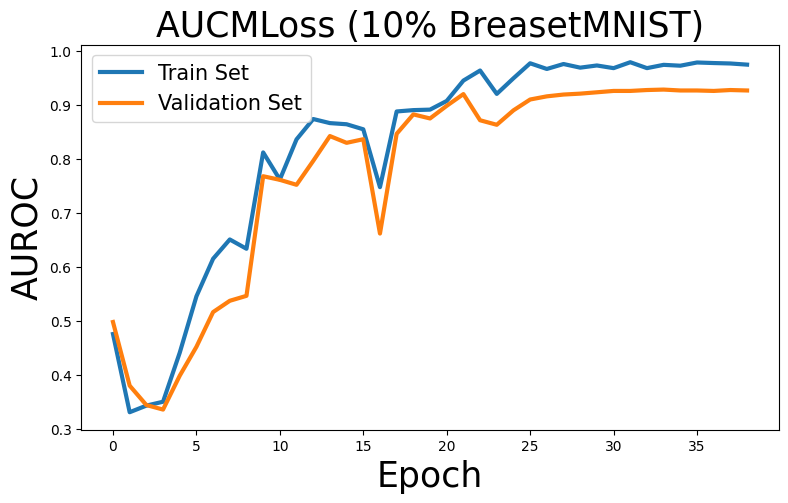

In [25]:
plt.rcParams["figure.figsize"] = (9,5)
x=np.arange(len(train_log))
plt.figure()
plt.plot(x, train_log, linestyle='-', label='Train Set', linewidth=3)
plt.plot(x, val_log,  linestyle='-', label='Validation Set', linewidth=3)
plt.title('AUCMLoss (10% BreasetMNIST)',fontsize=25)
plt.legend(fontsize=15)
plt.ylabel('AUROC', fontsize=25)
plt.xlabel('Epoch', fontsize=25)

In [26]:
test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE)

In [27]:
# test ROC-AUC (the trainer already moved the model to `device`)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.eval()  # eval mode: BatchNorm uses running statistics
# scores are raw logits, fine for ROC-AUC
score_list = list()
label_list = list()
for _, d in enumerate(test_loader, 0):
    tmp_data, tmp_label = d
    tmp_data = tmp_data.to(device)
    tmp_score = model(tmp_data).detach().clone().cpu()
    score_list.append(tmp_score)
    label_list.append(tmp_label.cpu())

test_label = torch.cat(label_list)
test_score = torch.cat(score_list)

test_auc = metrics.roc_auc_score(test_label, test_score)
print("Test : %.4f"%test_auc, flush=True)

Test : 0.8993


In [28]:
torch.save(model.state_dict(), "breast_model1.pth")

### Model 2: flip + normalize

In [29]:
# Model 2: flip + normalize (val/test get the same normalization)
train_d = OnTheFlyAugment(train_dataset1, make_augment_with_normalize([flip_aug]))
val_d2 = OnTheFlyAugment(val_dataset1, normalize_aug)
# DualSampler: sampling_rate 0.7 gives ~30% malignant per batch, see Overview
sampler_dual = DualSampler(train_d, batch_size=BATCH_SIZE, labels=train_dataset1.labels, sampling_rate=0.7)
trainloader = data.DataLoader(dataset=train_d, batch_size=BATCH_SIZE, sampler=sampler_dual)
valloader = data.DataLoader(dataset=val_d2, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
trainloader_eval = data.DataLoader(train_d, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [30]:
# ResNet-20: CIFAR-style stem, see Overview
from libauc.models import resnet20 as ResNet20

model2 = ResNet20(pretrained=False, last_activation=None, num_classes=1)
model2.conv1 = torch.nn.Conv2d(n_channels, 16, kernel_size=3, stride=1, padding=1, bias=False)

# HyperParameters
BATCH_SIZE = 128
total_epochs = 50
decay_epochs = [25, 40]  # 50% / 80% of total_epochs

lr = 0.05
margin = 1.0
epoch_decay = 0.003  # PESG's gamma
weight_decay = 0.0005


# loss and optimizer
loss_fn = AUCMLoss_V2(margin=margin)  # needs the DualSampler (see Overview)
optimizer = PESG(model2,
                 loss_fn=loss_fn,
                 lr=lr,
                 momentum=0.9,
                 margin=margin,
                 epoch_decay=epoch_decay,
                 weight_decay=weight_decay)




In [31]:
patience = 12

train_log, val_log = train(model2, loss_fn, optimizer, total_epochs, trainloader, trainloader_eval,
                           valloader, patience=patience, decay_epochs=decay_epochs)

Start Training
------------------------------
device: cuda
epoch: 0, train_loss: 0.3251, train_auc: 0.6398, val_auc: 0.5589, lr: 0.0500
0
epoch: 1, train_loss: 0.6754, train_auc: 0.6420, val_auc: 0.5539, lr: 0.0500
1
epoch: 2, train_loss: 0.8473, train_auc: 0.6260, val_auc: 0.5831, lr: 0.0500
0
epoch: 3, train_loss: 0.8829, train_auc: 0.6423, val_auc: 0.5881, lr: 0.0500
0
epoch: 4, train_loss: 0.8175, train_auc: 0.6540, val_auc: 0.6032, lr: 0.0500
0
epoch: 5, train_loss: 0.7079, train_auc: 0.6871, val_auc: 0.6307, lr: 0.0500
0
epoch: 6, train_loss: 0.6015, train_auc: 0.6981, val_auc: 0.6383, lr: 0.0500
0
epoch: 7, train_loss: 0.5210, train_auc: 0.7630, val_auc: 0.6750, lr: 0.0500
0
epoch: 8, train_loss: 0.5801, train_auc: 0.8409, val_auc: 0.7444, lr: 0.0500
0
epoch: 9, train_loss: 0.5206, train_auc: 0.8767, val_auc: 0.7903, lr: 0.0500
0
epoch: 10, train_loss: 0.3552, train_auc: 0.9116, val_auc: 0.8338, lr: 0.0500
0
epoch: 11, train_loss: 0.2874, train_auc: 0.8714, val_auc: 0.7410, lr: 

Text(0.5, 0, 'Epoch')

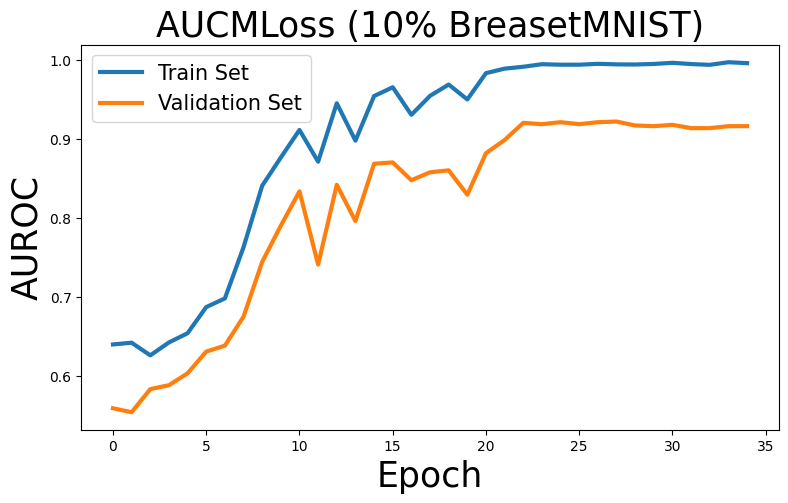

In [32]:
plt.rcParams["figure.figsize"] = (9,5)
x=np.arange(len(train_log))
plt.figure()
plt.plot(x, train_log, linestyle='-', label='Train Set', linewidth=3)
plt.plot(x, val_log,  linestyle='-', label='Validation Set', linewidth=3)
plt.title('AUCMLoss (10% BreasetMNIST)',fontsize=25)
plt.legend(fontsize=15)
plt.ylabel('AUROC', fontsize=25)
plt.xlabel('Epoch', fontsize=25)

In [33]:
# Model 2 trains on normalized images, so test gets the same normalization
test_dataset2 = OnTheFlyAugment(test_dataset, normalize_aug)
test_loader = data.DataLoader(dataset=test_dataset2, batch_size=BATCH_SIZE)

# test ROC-AUC (the trainer already moved the model to `device`)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model2.eval()  # eval mode: BatchNorm uses running statistics
score_list = list()
label_list = list()
for _, d in enumerate(test_loader, 0):
    tmp_data, tmp_label = d
    tmp_data = tmp_data.to(device)
    tmp_score = model2(tmp_data).detach().clone().cpu()
    score_list.append(tmp_score)
    label_list.append(tmp_label.cpu())

test_label = torch.cat(label_list)
test_score = torch.cat(score_list)

test_auc = metrics.roc_auc_score(test_label, test_score)
print("Test : %.4f"%test_auc, flush=True)

Test : 0.8937


In [34]:
torch.save(model2.state_dict(), "breast_model2.pth")

### Model 3: noise + normalize

In [35]:
# Model 3: noise + normalize (val/test get the same normalization)
train_d = OnTheFlyAugment(train_dataset1, make_augment_with_normalize([noise_aug]))
val_d3 = OnTheFlyAugment(val_dataset1, normalize_aug)
# DualSampler: sampling_rate 0.7 gives ~30% malignant per batch, see Overview
sampler_dual = DualSampler(train_d, batch_size=BATCH_SIZE, labels=train_dataset1.labels, sampling_rate=0.7)
trainloader = data.DataLoader(dataset=train_d, batch_size=BATCH_SIZE, sampler=sampler_dual)
valloader = data.DataLoader(dataset=val_d3, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
trainloader_eval = data.DataLoader(train_d, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [36]:
# ResNet-20: CIFAR-style stem, see Overview
from libauc.models import resnet20 as ResNet20

model3 = ResNet20(pretrained=False, last_activation=None, num_classes=1, )
model3.conv1 = torch.nn.Conv2d(n_channels, 16, kernel_size=3, stride=1, padding=1, bias=False)

# HyperParameters
BATCH_SIZE = 128
total_epochs = 50
decay_epochs = [25, 40]  # 50% / 80% of total_epochs

lr = 0.05
margin = 1.0
epoch_decay = 0.003  # PESG's gamma
weight_decay = 0.0005


# loss and optimizer
loss_fn = AUCMLoss_V2(margin=margin)  # needs the DualSampler (see Overview)
optimizer = PESG(model3,
                 loss_fn=loss_fn,
                 lr=lr,
                 momentum=0.9,
                 margin=margin,
                 epoch_decay=epoch_decay,
                 weight_decay=weight_decay)





In [37]:
train_log, val_log = train(model3, loss_fn, optimizer, total_epochs, trainloader, trainloader_eval, valloader,
      patience=patience, decay_epochs=decay_epochs)

Start Training
------------------------------
device: cuda
epoch: 0, train_loss: 1.2505, train_auc: 0.6197, val_auc: 0.5714, lr: 0.0500
0
epoch: 1, train_loss: 0.6606, train_auc: 0.6475, val_auc: 0.6182, lr: 0.0500
0
epoch: 2, train_loss: 0.7969, train_auc: 0.6532, val_auc: 0.6282, lr: 0.0500
0
epoch: 3, train_loss: 0.8264, train_auc: 0.6621, val_auc: 0.6232, lr: 0.0500
1
epoch: 4, train_loss: 0.8307, train_auc: 0.6548, val_auc: 0.6157, lr: 0.0500
2
epoch: 5, train_loss: 0.7562, train_auc: 0.6729, val_auc: 0.6449, lr: 0.0500
0
epoch: 6, train_loss: 0.7507, train_auc: 0.6225, val_auc: 0.5731, lr: 0.0500
1
epoch: 7, train_loss: 0.6461, train_auc: 0.6968, val_auc: 0.6700, lr: 0.0500
0
epoch: 8, train_loss: 0.6457, train_auc: 0.7029, val_auc: 0.6600, lr: 0.0500
1
epoch: 9, train_loss: 0.5656, train_auc: 0.8110, val_auc: 0.7945, lr: 0.0500
0
epoch: 10, train_loss: 0.5491, train_auc: 0.7384, val_auc: 0.8037, lr: 0.0500
0
epoch: 11, train_loss: 0.5408, train_auc: 0.8480, val_auc: 0.8003, lr: 

Text(0.5, 0, 'Epoch')

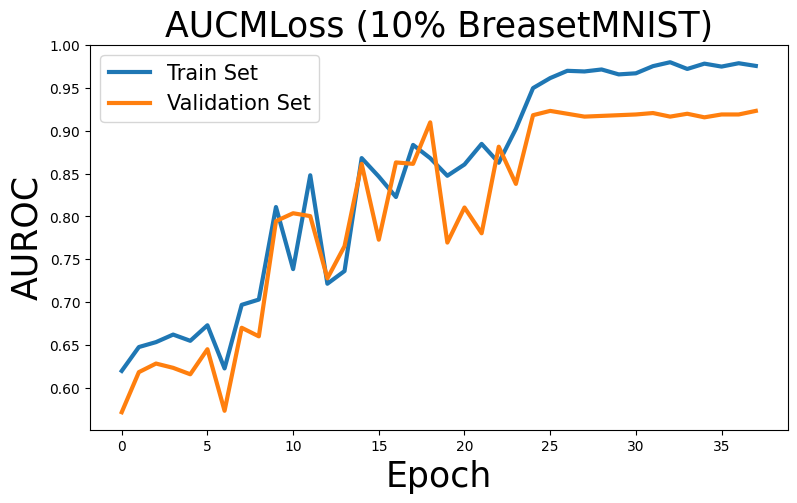

In [38]:
plt.rcParams["figure.figsize"] = (9,5)
x=np.arange(len(train_log))
plt.figure()
plt.plot(x, train_log, linestyle='-', label='Train Set', linewidth=3)
plt.plot(x, val_log,  linestyle='-', label='Validation Set', linewidth=3)
plt.title('AUCMLoss (10% BreasetMNIST)',fontsize=25)
plt.legend(fontsize=15)
plt.ylabel('AUROC', fontsize=25)
plt.xlabel('Epoch', fontsize=25)

In [39]:
# Model 3 trains on normalized images, so test gets the same normalization
test_dataset3 = OnTheFlyAugment(test_dataset, normalize_aug)
test_loader = data.DataLoader(dataset=test_dataset3, batch_size=BATCH_SIZE)

# test ROC-AUC (the trainer already moved the model to `device`)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model3.eval()  # eval mode: BatchNorm uses running statistics
score_list = list()
label_list = list()
for _, d in enumerate(test_loader, 0):
    tmp_data, tmp_label = d
    tmp_data = tmp_data.to(device)
    tmp_score = model3(tmp_data).detach().clone().cpu()
    score_list.append(tmp_score)
    label_list.append(tmp_label.cpu())

test_label = torch.cat(label_list)
test_score = torch.cat(score_list)

test_auc = metrics.roc_auc_score(test_label, test_score)
print("Test : %.4f"%test_auc, flush=True)

Test : 0.8381


In [40]:
torch.save(model3.state_dict(), "breast_model3.pth")

### Model 4: flip + noise + normalize

In [41]:
# Model 4: flip + noise + normalize (val/test get the same normalization)
train_d = OnTheFlyAugment(train_dataset1, make_augment_with_normalize([flip_aug, noise_aug]))
val_d4 = OnTheFlyAugment(val_dataset1, normalize_aug)
# DualSampler: sampling_rate 0.7 gives ~30% malignant per batch, see Overview
sampler_dual = DualSampler(train_d, batch_size=BATCH_SIZE, labels=train_dataset1.labels, sampling_rate=0.7)
trainloader = data.DataLoader(dataset=train_d, batch_size=BATCH_SIZE, sampler=sampler_dual)
valloader = data.DataLoader(dataset=val_d4, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
trainloader_eval = data.DataLoader(train_d, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [42]:
# ResNet-20: CIFAR-style stem, see Overview
from libauc.models import resnet20 as ResNet20

model4 = ResNet20(pretrained=False, last_activation=None, num_classes=1, )
model4.conv1 = torch.nn.Conv2d(n_channels, 16, kernel_size=3, stride=1, padding=1, bias=False)

# HyperParameters
BATCH_SIZE = 128
total_epochs = 50
decay_epochs = [25, 40]  # 50% / 80% of total_epochs

lr = 0.05
margin = 1.0
epoch_decay = 0.003  # PESG's gamma
weight_decay = 0.0005


# loss and optimizer
loss_fn = AUCMLoss_V2(margin=margin)  # needs the DualSampler (see Overview)
optimizer = PESG(model4,
                 loss_fn=loss_fn,
                 lr=lr,
                 momentum=0.9,
                 margin=margin,
                 epoch_decay=epoch_decay,
                 weight_decay=weight_decay)





In [43]:
train_log, val_log = train(model4, loss_fn, optimizer, total_epochs, trainloader, trainloader_eval, valloader,
      patience=patience, decay_epochs=decay_epochs)

Start Training
------------------------------
device: cuda
epoch: 0, train_loss: 0.2780, train_auc: 0.4622, val_auc: 0.5313, lr: 0.0500
0
epoch: 1, train_loss: 0.6751, train_auc: 0.6125, val_auc: 0.7034, lr: 0.0500
0
epoch: 2, train_loss: 0.8556, train_auc: 0.6294, val_auc: 0.6809, lr: 0.0500
1
epoch: 3, train_loss: 0.9221, train_auc: 0.6402, val_auc: 0.6558, lr: 0.0500
2
epoch: 4, train_loss: 0.9420, train_auc: 0.6416, val_auc: 0.6717, lr: 0.0500
0
epoch: 5, train_loss: 0.9209, train_auc: 0.6699, val_auc: 0.6558, lr: 0.0500
1
epoch: 6, train_loss: 0.8682, train_auc: 0.6608, val_auc: 0.6658, lr: 0.0500
0
epoch: 7, train_loss: 0.8384, train_auc: 0.6831, val_auc: 0.6650, lr: 0.0500
1
epoch: 8, train_loss: 0.8639, train_auc: 0.6953, val_auc: 0.6759, lr: 0.0500
0
epoch: 9, train_loss: 0.8079, train_auc: 0.7032, val_auc: 0.6825, lr: 0.0500
0
epoch: 10, train_loss: 0.7544, train_auc: 0.7257, val_auc: 0.6834, lr: 0.0500
1
epoch: 11, train_loss: 0.7793, train_auc: 0.7115, val_auc: 0.7168, lr: 

Text(0.5, 0, 'Epoch')

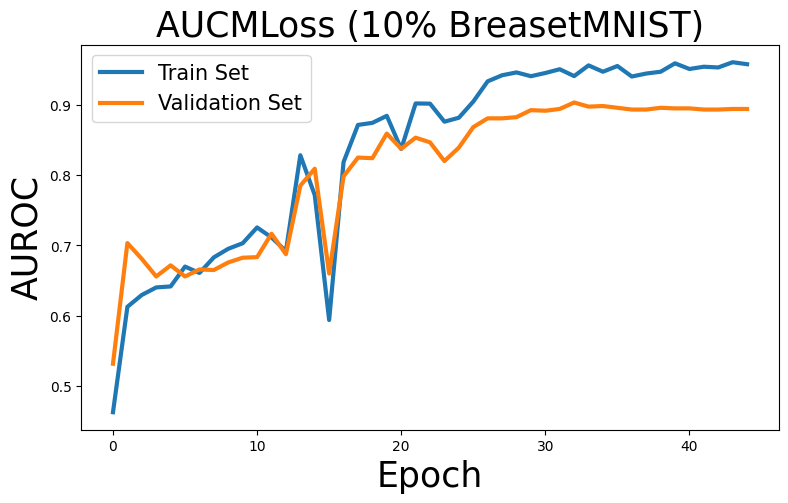

In [44]:
plt.rcParams["figure.figsize"] = (9,5)
x=np.arange(len(train_log))
plt.figure()
plt.plot(x, train_log, linestyle='-', label='Train Set', linewidth=3)
plt.plot(x, val_log,  linestyle='-', label='Validation Set', linewidth=3)
plt.title('AUCMLoss (10% BreasetMNIST)',fontsize=25)
plt.legend(fontsize=15)
plt.ylabel('AUROC', fontsize=25)
plt.xlabel('Epoch', fontsize=25)

In [45]:
# Model 4 trains on normalized images, so test gets the same normalization
test_dataset4 = OnTheFlyAugment(test_dataset, normalize_aug)
test_loader = data.DataLoader(dataset=test_dataset4, batch_size=BATCH_SIZE)

# test ROC-AUC (the trainer already moved the model to `device`)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model4.eval()  # eval mode: BatchNorm uses running statistics
score_list = list()
label_list = list()
for _, d in enumerate(test_loader, 0):
    tmp_data, tmp_label = d
    tmp_data = tmp_data.to(device)
    tmp_score = model4(tmp_data).detach().clone().cpu()
    score_list.append(tmp_score)
    label_list.append(tmp_label.cpu())

test_label = torch.cat(label_list)
test_score = torch.cat(score_list)

test_auc = metrics.roc_auc_score(test_label, test_score)
print("Test : %.4f"%test_auc, flush=True)

Test : 0.8659


In [46]:
torch.save(model4.state_dict(), "breast_model4.pth")

## Optuna tuning

Optuna searches the Model 4 recipe, then one model is retrained with the best parameters.

- 30 trials, `TPESampler` (10 random startup trials), objective = best validation ROC-AUC within the trial. Each trial trains up to 10 epochs (decay at 5 and 8, patience 4). A trial that diverges to NaN is recorded as failed.
- Retrain: best parameters, up to 50 epochs, decay at 25 and 40, patience 12.

### Search space

| Parameter | Range |
|---|---|
| `batch_size` | categorical {128, 256} |
| `sampling_rate` | uniform [0.6, 0.73] (27 to 40% malignant per batch) |
| `lr` | log-uniform [0.02, 0.15] |
| `weight_decay` | log-uniform [2e-4, 1.5e-3] |
| `margin` | uniform [0.8, 1.3] |
| `epoch_decay` | log-uniform [1e-3, 8e-3] |

`lr` and `weight_decay` span about 3x either side of Model 4's values. `margin` and `epoch_decay` are narrow ranges around them.

### Best trial

Best parameters: batch size 128, sampling_rate 0.613, lr 0.113, weight decay 6.8e-4, margin 1.018, epoch_decay 7.1e-3. `sampling_rate` sits near the low end of its range and `epoch_decay` near the high end. The search best is 0.811 validation ROC-AUC at the 10-epoch budget (trial scores 0.53 to 0.81), so it isn't comparable to the retrained model's validation AUC (0.935).

In [47]:
# Optuna search for the Model 4 recipe. Every trial builds its own loaders, sampler, model and optimizer.
# search budget: 10 epochs, decay at 5 and 8 (50% / 80% of 10), patience 4

SEARCH_TOTAL_EPOCHS = 10
SEARCH_DECAY_EPOCHS = [5, 8]
SEARCH_PATIENCE = 4


def build_model(trial):
    model_trial = ResNet20(pretrained=False, last_activation=None, num_classes=1)
    model_trial.conv1 = torch.nn.Conv2d(n_channels, 16, kernel_size=3, stride=1, padding=1, bias=False)
    return model_trial


def build_loaders(trial):
    trial_batch_size = trial.suggest_categorical('batch_size', [128, 256])
    # sampling_rate: share of each batch from label 1 (majority), so [0.6, 0.73] gives 27 to 40% malignant
    trial_sampling_rate = trial.suggest_float('sampling_rate', 0.6, 0.73)

    # val gets the same normalization
    train_d_trial = OnTheFlyAugment(train_dataset1, make_augment_with_normalize([flip_aug, noise_aug]))
    val_d_trial_norm = OnTheFlyAugment(val_dataset1, normalize_aug)
    # rebuilt per trial because the per-batch split depends on batch_size
    sampler_dual_trial = DualSampler(train_d_trial, batch_size=trial_batch_size,
                                      labels=train_dataset1.labels, sampling_rate=trial_sampling_rate)
    trainloader_trial = data.DataLoader(dataset=train_d_trial, batch_size=trial_batch_size,
                                         sampler=sampler_dual_trial)
    trainloader_eval_trial = data.DataLoader(train_d_trial, batch_size=trial_batch_size,
                                              shuffle=False, num_workers=2)
    valloader_trial = data.DataLoader(dataset=val_d_trial_norm, batch_size=trial_batch_size,
                                       shuffle=False, num_workers=2)
    return trainloader_trial, trainloader_eval_trial, valloader_trial


def build_loss_optimizer(trial, model):
    # lr, weight_decay: log-uniform, about 3x either side of Model 4's values
    trial_lr = trial.suggest_float('lr', 2e-2, 1.5e-1, log=True)
    trial_weight_decay = trial.suggest_float('weight_decay', 2e-4, 1.5e-3, log=True)
    # margin, epoch_decay: narrow ranges around Model 4's values
    trial_margin = trial.suggest_float('margin', 0.8, 1.3)
    trial_epoch_decay = trial.suggest_float('epoch_decay', 1e-3, 8e-3, log=True)

    # needs the DualSampler from build_loaders
    loss_fn = AUCMLoss_V2(margin=trial_margin)
    optimizer = PESG(model,
                      loss_fn=loss_fn,
                      lr=trial_lr,
                      momentum=0.9,
                      margin=trial_margin,
                      epoch_decay=trial_epoch_decay,
                      weight_decay=trial_weight_decay)
    return loss_fn, optimizer


def score_fn(model, valloader, train_fn_result):
    # best val ROC-AUC in the trial (train_fn_result[1] is val_log)
    return max(train_fn_result[1])


In [48]:
# 30 trials, more than the 10 random startup trials, so later ones are model-guided
# catch=(ValueError,): a NaN trial (roc_auc_score raises) is recorded as failed and the search continues
from hyperparameter_tuning import run_optuna_search, retrain_with_best_params

study = run_optuna_search(build_model, build_loaders, build_loss_optimizer, train, score_fn,
                           n_trials=30, search_epochs=SEARCH_TOTAL_EPOCHS,
                           search_decay_epochs=SEARCH_DECAY_EPOCHS,
                           search_patience=SEARCH_PATIENCE,
                           catch=(ValueError,))

print(study.best_params)
print(study.best_value)


[I 2026-09-24 09:04:21,530] A new study created in memory with name: no-name-891867d1-3587-40a0-af55-f9f7ea7e17b4


Start Training
------------------------------
device: cuda
epoch: 0, train_loss: 0.1367, train_auc: 0.6628, val_auc: 0.6683, lr: 0.0927
0
epoch: 1, train_loss: 0.4144, train_auc: 0.5468, val_auc: 0.6458, lr: 0.0927
1
epoch: 2, train_loss: 0.5450, train_auc: 0.4043, val_auc: 0.5263, lr: 0.0927
2
epoch: 3, train_loss: 0.5974, train_auc: 0.3934, val_auc: 0.4520, lr: 0.0927
3
epoch: 4, train_loss: 0.6077, train_auc: 0.4087, val_auc: 0.4578, lr: 0.0927
0
Reducing learning rate to 0.00927 @ T=10!
Updating regularizer @ T=10!
epoch: 5, train_loss: 0.5914, train_auc: 0.3848, val_auc: 0.4436, lr: 0.0093
1
epoch: 6, train_loss: 0.5908, train_auc: 0.3915, val_auc: 0.4495, lr: 0.0093
0
epoch: 7, train_loss: 0.5959, train_auc: 0.4282, val_auc: 0.4779, lr: 0.0093
0
Reducing learning rate to 0.00093 @ T=16!
Updating regularizer @ T=16!
epoch: 8, train_loss: 0.5928, train_auc: 0.4627, val_auc: 0.5155, lr: 0.0009
0


[I 2026-09-24 09:04:25,657] Trial 0 finished with value: 0.6683375104427736 and parameters: {'batch_size': 256, 'sampling_rate': 0.6129648386805759, 'lr': 0.09270761190669925, 'weight_decay': 0.00022351612583191218, 'margin': 0.8096870859926737, 'epoch_decay': 0.0027667211927953485}. Best is trial 0 with value: 0.6683375104427736.


epoch: 9, train_loss: 0.5821, train_auc: 0.5321, val_auc: 0.5614, lr: 0.0009
0
Restoring best checkpoint: epoch 0, val_auc 0.6683
Start Training
------------------------------
device: cuda
epoch: 0, train_loss: 0.3398, train_auc: 0.6582, val_auc: 0.6316, lr: 0.1328
0
epoch: 1, train_loss: 0.6588, train_auc: 0.6518, val_auc: 0.6408, lr: 0.1328
0
epoch: 2, train_loss: 0.7845, train_auc: 0.6450, val_auc: 0.6424, lr: 0.1328
1
epoch: 3, train_loss: 0.8215, train_auc: 0.6193, val_auc: 0.6307, lr: 0.1328
2
epoch: 4, train_loss: 0.8320, train_auc: 0.6167, val_auc: 0.6182, lr: 0.1328
3
Reducing learning rate to 0.01328 @ T=10!
Updating regularizer @ T=10!


[I 2026-09-24 09:04:28,113] Trial 1 finished with value: 0.6424394319131161 and parameters: {'batch_size': 256, 'sampling_rate': 0.6886905394521402, 'lr': 0.13279541285420066, 'weight_decay': 0.000536756913866611, 'margin': 0.9149346715494445, 'epoch_decay': 0.0021726452792992512}. Best is trial 0 with value: 0.6683375104427736.


...

epoch: 8, train_loss: 0.6919, train_auc: 0.7488, val_auc: 0.7001, lr: 0.0012
4
Early stopping
Restoring best checkpoint: epoch 4, val_auc 0.7277
Start Training
------------------------------
device: cuda
epoch: 0, train_loss: 0.5690, train_auc: 0.3742, val_auc: 0.3325, lr: 0.1062
0
epoch: 1, train_loss: 0.9730, train_auc: 0.5824, val_auc: 0.5288, lr: 0.1062
0
epoch: 2, train_loss: 0.9990, train_auc: 0.5944, val_auc: 0.5330, lr: 0.1062
1
epoch: 3, train_loss: 0.9345, train_auc: 0.6298, val_auc: 0.5681, lr: 0.1062
0
epoch: 4, train_loss: 0.8589, train_auc: 0.6882, val_auc: 0.6358, lr: 0.1062
0
Reducing learning rate to 0.01062 @ T=25!
Updating regularizer @ T=25!
epoch: 5, train_loss: 0.8117, train_auc: 0.7087, val_auc: 0.6508, lr: 0.0106
0
epoch: 6, train_loss: 0.7943, train_auc: 0.7108, val_auc: 0.6617, lr: 0.0106
0
epoch: 7, train_loss: 0.7850, train_auc: 0.7331, val_auc: 0.6909, lr: 0.0106
0
Reducing learning rate to 0.00106 @ T=40!
Updating regularizer @ T=40!
epoch: 8, train_loss: 

[I 2026-09-24 09:06:25,579] Trial 28 finished with value: 0.7076023391812865 and parameters: {'batch_size': 128, 'sampling_rate': 0.6054279028069718, 'lr': 0.10616840807535378, 'weight_decay': 0.0012246248782655453, 'margin': 1.00808704757239, 'epoch_decay': 0.007493713634059422}. Best is trial 26 with value: 0.8111946532999165.


epoch: 9, train_loss: 0.7281, train_auc: 0.7446, val_auc: 0.7076, lr: 0.0011
0
Restoring best checkpoint: epoch 9, val_auc 0.7076
Start Training
------------------------------
device: cuda
epoch: 0, train_loss: 0.6273, train_auc: 0.4948, val_auc: 0.3985, lr: 0.1173
0
epoch: 1, train_loss: 0.7464, train_auc: 0.4003, val_auc: 0.2907, lr: 0.1173
1
epoch: 2, train_loss: 0.7670, train_auc: 0.4447, val_auc: 0.3634, lr: 0.1173
0
epoch: 3, train_loss: 0.7682, train_auc: 0.4809, val_auc: 0.4403, lr: 0.1173
0
epoch: 4, train_loss: 0.7682, train_auc: 0.5660, val_auc: 0.4829, lr: 0.1173
0
Reducing learning rate to 0.01173 @ T=25!
Updating regularizer @ T=25!
epoch: 5, train_loss: 0.7681, train_auc: 0.5529, val_auc: 0.4921, lr: 0.0117
0
epoch: 6, train_loss: 0.7682, train_auc: 0.5664, val_auc: 0.4987, lr: 0.0117
0
epoch: 7, train_loss: 0.7682, train_auc: 0.5608, val_auc: 0.4937, lr: 0.0117
1
Reducing learning rate to 0.00117 @ T=40!
Updating regularizer @ T=40!
epoch: 8, train_loss: 0.7681, train_a

[I 2026-09-24 09:06:30,456] Trial 29 finished with value: 0.531328320802005 and parameters: {'batch_size': 128, 'sampling_rate': 0.6140198580378766, 'lr': 0.1172611906026518, 'weight_decay': 0.0005141322049327999, 'margin': 0.8767012438299433, 'epoch_decay': 0.006833006244791957}. Best is trial 26 with value: 0.8111946532999165.


epoch: 9, train_loss: 0.7679, train_auc: 0.5926, val_auc: 0.5313, lr: 0.0012
0
Restoring best checkpoint: epoch 9, val_auc 0.5313
{'batch_size': 128, 'sampling_rate': 0.6131910528343147, 'lr': 0.11327819647310737, 'weight_decay': 0.0006770513071299288, 'margin': 1.017827762618961, 'epoch_decay': 0.007068731148163642}
0.8111946532999165


In [49]:
# retrain with the best params at the full budget, through the same build_* callables as the search
model_optuna, loss_fn_optuna, optimizer_optuna, (train_log_optuna, val_log_optuna) = retrain_with_best_params(
    study, build_model, build_loaders, build_loss_optimizer, train,
    full_epochs=50, full_decay_epochs=[25, 40], full_patience=12)

# best_params supplies the test batch size below
best_params = study.best_params


Start Training
------------------------------
device: cuda
epoch: 0, train_loss: 0.8832, train_auc: 0.4902, val_auc: 0.3651, lr: 0.1133
0
epoch: 1, train_loss: 0.9346, train_auc: 0.5819, val_auc: 0.4896, lr: 0.1133
0
epoch: 2, train_loss: 0.8412, train_auc: 0.5589, val_auc: 0.4687, lr: 0.1133
1
epoch: 3, train_loss: 0.7401, train_auc: 0.5868, val_auc: 0.5280, lr: 0.1133
0
epoch: 4, train_loss: 0.7089, train_auc: 0.7150, val_auc: 0.6508, lr: 0.1133
0
epoch: 5, train_loss: 0.6177, train_auc: 0.7684, val_auc: 0.7051, lr: 0.1133
0
epoch: 6, train_loss: 0.5839, train_auc: 0.8209, val_auc: 0.7753, lr: 0.1133
0
epoch: 7, train_loss: 0.5028, train_auc: 0.8611, val_auc: 0.7978, lr: 0.1133
0
epoch: 8, train_loss: 0.4348, train_auc: 0.8552, val_auc: 0.8789, lr: 0.1133
0
epoch: 9, train_loss: 0.5053, train_auc: 0.8843, val_auc: 0.8120, lr: 0.1133
1
epoch: 10, train_loss: 0.3925, train_auc: 0.9080, val_auc: 0.8179, lr: 0.1133
0
epoch: 11, train_loss: 0.3690, train_auc: 0.8913, val_auc: 0.8145, lr: 

In [50]:
# tuned model trains on normalized images, so test gets the same normalization
test_dataset_optuna = OnTheFlyAugment(test_dataset, normalize_aug)
test_loader_optuna = data.DataLoader(dataset=test_dataset_optuna, batch_size=best_params['batch_size'])

# test ROC-AUC (the trainer already moved the model to `device`)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_optuna.eval()  # eval mode: BatchNorm uses running statistics
score_list = list()
label_list = list()
for _, d in enumerate(test_loader_optuna, 0):
    tmp_data, tmp_label = d
    tmp_data = tmp_data.to(device)
    tmp_score = model_optuna(tmp_data).detach().clone().cpu()
    score_list.append(tmp_score)
    label_list.append(tmp_label.cpu())

test_label = torch.cat(label_list)
test_score = torch.cat(score_list)

test_auc = metrics.roc_auc_score(test_label, test_score)
print("Test : %.4f"%test_auc, flush=True)

Test : 0.8764


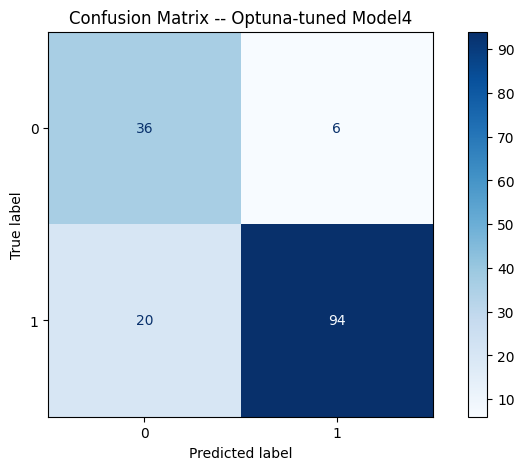

              precision    recall  f1-score   support

           0     0.6429    0.8571    0.7347        42
           1     0.9400    0.8246    0.8785       114

    accuracy                         0.8333       156
   macro avg     0.7914    0.8409    0.8066       156
weighted avg     0.8600    0.8333    0.8398       156

Balanced accuracy: 0.8409
PR-AUC (average precision): 0.9368
Matthews correlation coefficient: 0.6303


In [51]:
# confusion matrix and threshold metrics at 0.5 for the Optuna-tuned model
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                              balanced_accuracy_score, average_precision_score, matthews_corrcoef)

prob = torch.sigmoid(test_score).numpy().reshape(-1)  # test_score is a raw logit
y_true = test_label.numpy().astype(int).reshape(-1)
y_pred = (prob >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title('Confusion Matrix -- Optuna-tuned Model4')
plt.show()

print(classification_report(y_true, y_pred, digits=4))
print('Balanced accuracy: %.4f' % balanced_accuracy_score(y_true, y_pred))
# PR-AUC is for label 1 (normal/benign, the majority class)
print('PR-AUC (average precision): %.4f' % average_precision_score(y_true, prob))
print('Matthews correlation coefficient: %.4f' % matthews_corrcoef(y_true, y_pred))

In [52]:
torch.save(model_optuna.state_dict(), "breast_model4_optuna.pth")

## Results

Test set: 156 images, 42 malignant (label 0). Val ROC-AUC is the restored checkpoint's, with its 0-based epoch in parentheses. '-' means not computed.

| Arm | Val ROC-AUC (epoch) | Test ROC-AUC | Bal. acc. @0.5 | MCC @0.5 | PR-AUC (label 1) | Malignant recall / precision / F1 @0.5 |
|---|---|---|---|---|---|---|
| Baseline (ResNet-18, BCE + Adam) | 0.9449 (33) | 0.8127 | 0.6491 | 0.4141 | 0.8871 | 0.3333 / 0.7778 / 0.4667 |
| Hand-picked Model 1: flip + noise | 0.9282 (33) | 0.8993 | - | - | - | - |
| Hand-picked Model 2: flip + normalize | 0.9223 (27) | 0.8937 | - | - | - | - |
| Hand-picked Model 3: noise + normalize | 0.9231 (25) | 0.8381 | - | - | - | - |
| Hand-picked Model 4: flip + noise + normalize | 0.9039 (32) | 0.8659 | - | - | - | - |
| Optuna-tuned (Model 4 recipe) | 0.9348 (27) | 0.8764 | 0.8409 | 0.6303 | 0.9368 | 0.8571 / 0.6429 / 0.7347 |

Only the Baseline and Optuna-tuned have every metric. PR-AUC is for label 1 (normal/benign, the majority), so it is high by construction and says little about the malignant class.

Optuna best params: batch size 128, sampling_rate 0.613, lr 0.113, weight decay 6.8e-4, margin 1.018, epoch_decay 7.1e-3.

### Takeaways

- Optuna-tuned beats the Baseline on ROC-AUC, PR-AUC, balanced accuracy, MCC and malignant recall and F1. The Baseline has the higher malignant precision (0.778 vs. 0.643), so there is no single winner.
- Model 1 has the highest test ROC-AUC of any arm (0.899 vs. 0.876 for Optuna-tuned) but no other metrics. All four hand-picked models beat the Baseline on ROC-AUC.
- Adding normalization to Model 1 (Model 4) did not help: 0.866 vs. 0.899. Tuning lifts Model 4 to 0.876, still below Models 1 and 2. Differences this small may be noise.
- Balanced accuracy, MCC and malignant recall/F1 are at 0.5, so they also reflect where each arm's scores sit relative to 0.5. ROC-AUC is the cleaner comparison. The arms also differ in stem, loss, optimizer, sampler and augmentation, so this compares recipes.

The test set is small (156 images, 42 malignant), so small gaps may be noise. Validation ROC-AUC (78 images) is higher than test ROC-AUC for every arm, so read the validation column as optimistic.